# Greater Bay Area Air Quality Trend Analysis (2015-2024)

**Author:** Haohang Zhao | MSc Energy & Sustainability (Climate Change), University of Southampton

This notebook analyses 10 years of monthly air quality monitoring data across 9 cities in China's Greater Bay Area (GBA). The analysis covers temporal trends, seasonal patterns, inter-city comparisons, and the impact of COVID-19 lockdowns on air quality.

**Data:** Monthly city-level averages of AQI, PM2.5, PM10, SO2, NO2, CO, O3 (2015-2024)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
})
palette = sns.color_palette('Set2', 9)

# Load data
df = pd.read_csv('../data/gba_air_quality_2015_2024.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f'Dataset: {len(df)} records, {df["city"].nunique()} cities, '
      f'{df["date"].min().strftime("%Y-%m")} to {df["date"].max().strftime("%Y-%m")}')
df.head()

Dataset: 1080 records, 9 cities, 2015-01 to 2024-12


,date,city,city_zh,lat,lon,AQI,PM2.5,PM10,SO2,NO2,CO,O3,year,month
0,2015-01-01,Dongguan,东莞,23.02,113.75,75.5,55.1,76.1,20.4,48.0,1.0,59.5,2015,1
1,2015-01-01,Foshan,佛山,23.02,113.12,74.5,54.3,80.2,24.5,60.0,1.2,36.0,2015,1
2,2015-01-01,Guangzhou,广州,23.13,113.26,73.0,53.0,76.7,18.2,61.6,1.3,32.7,2015,1
3,2015-01-01,Huizhou,惠州,23.11,114.42,56.3,34.2,65.7,12.1,29.8,1.0,62.2,2015,1
4,2015-01-01,Jiangmen,江门,22.58,113.08,87.6,64.8,87.1,31.1,54.8,1.4,49.2,2015,1


## 1. PM2.5 Ten-Year Trend by City

PM2.5 is the most health-relevant air pollutant and the primary driver of China's air quality improvement policies since 2013.

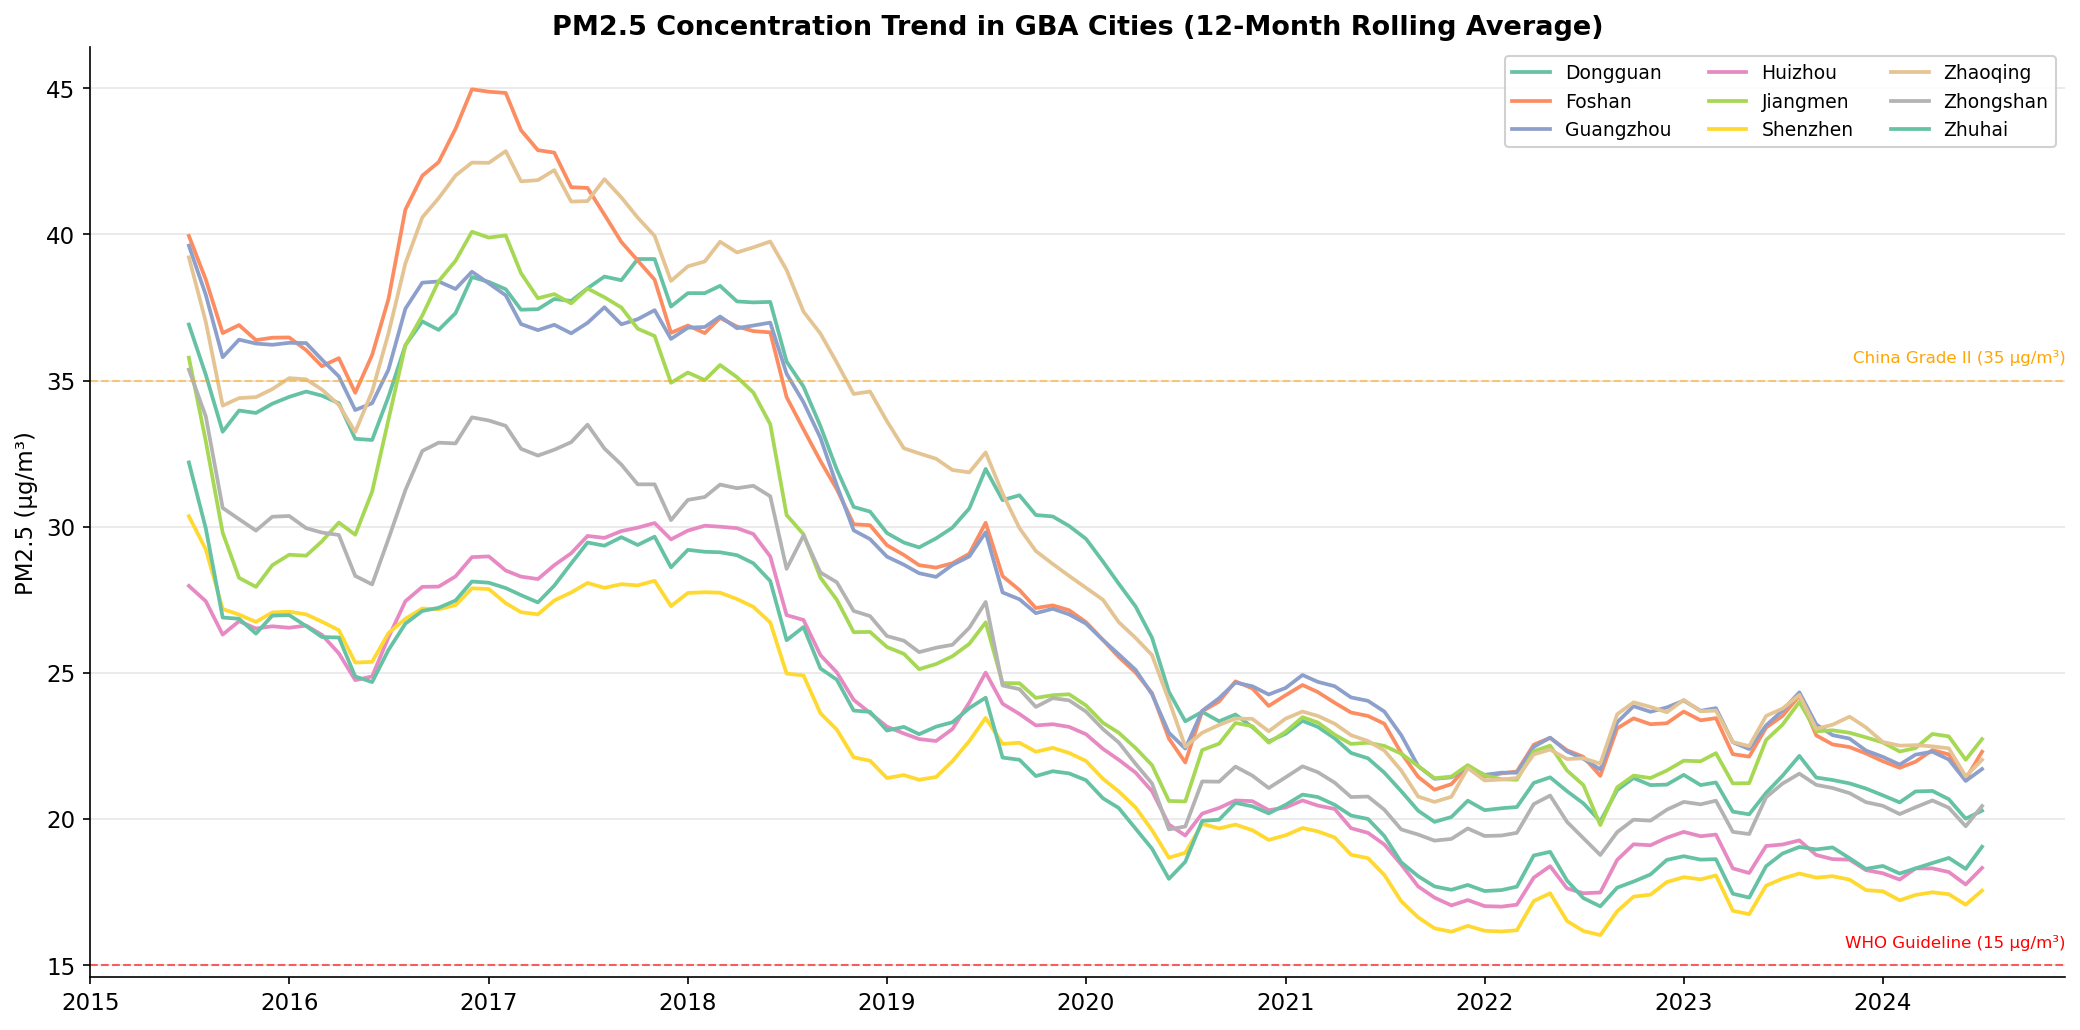


PM2.5 Decline (2015 vs 2024 annual average):
  Dongguan    :  36.9 →  20.3 µg/m³  (-45.1%)
  Foshan      :  39.9 →  22.3 µg/m³  (-44.2%)
  Guangzhou   :  39.6 →  21.7 µg/m³  (-45.2%)
  Huizhou     :  28.0 →  18.3 µg/m³  (-34.5%)
  Jiangmen    :  35.8 →  22.7 µg/m³  (-36.5%)
  Shenzhen    :  30.4 →  17.6 µg/m³  (-42.2%)
  Zhaoqing    :  39.2 →  22.0 µg/m³  (-43.8%)
  Zhongshan   :  35.4 →  20.4 µg/m³  (-42.2%)
  Zhuhai      :  32.2 →  19.0 µg/m³  (-40.8%)


In [2]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, city in enumerate(sorted(df['city'].unique())):
    city_data = df[df['city'] == city].sort_values('date')
    # 12-month rolling average for clarity
    rolling = city_data.set_index('date')['PM2.5'].rolling(12, center=True).mean()
    ax.plot(rolling.index, rolling.values, label=city, color=palette[i], linewidth=1.8)

# WHO guideline
ax.axhline(y=15, color='red', linestyle='--', alpha=0.6, linewidth=1)
ax.text(df['date'].max(), 15.5, 'WHO Guideline (15 µg/m³)', color='red',
        fontsize=8, ha='right', va='bottom')

# China standard
ax.axhline(y=35, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax.text(df['date'].max(), 35.5, 'China Grade II (35 µg/m³)', color='orange',
        fontsize=8, ha='right', va='bottom')

ax.set_title('PM2.5 Concentration Trend in GBA Cities (12-Month Rolling Average)', fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('')
ax.legend(ncol=3, loc='upper right', framealpha=0.9)
ax.set_xlim(df['date'].min(), df['date'].max())
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/pm25_trend_all_cities.png', dpi=200, bbox_inches='tight')
plt.show()

# Quantify decline
print('\nPM2.5 Decline (2015 vs 2024 annual average):')
print('=' * 50)
for city in sorted(df['city'].unique()):
    avg_2015 = df[(df['city'] == city) & (df['year'] == 2015)]['PM2.5'].mean()
    avg_2024 = df[(df['city'] == city) & (df['year'] == 2024)]['PM2.5'].mean()
    pct = (avg_2024 - avg_2015) / avg_2015 * 100
    print(f'  {city:12s}: {avg_2015:5.1f} → {avg_2024:5.1f} µg/m³  ({pct:+.1f}%)')

## 2. Multi-Pollutant Heatmap (Annual Averages)

Comparing how different pollutants have evolved over the decade. Note the divergence: PM2.5/SO2/NO2 decline while O3 rises.

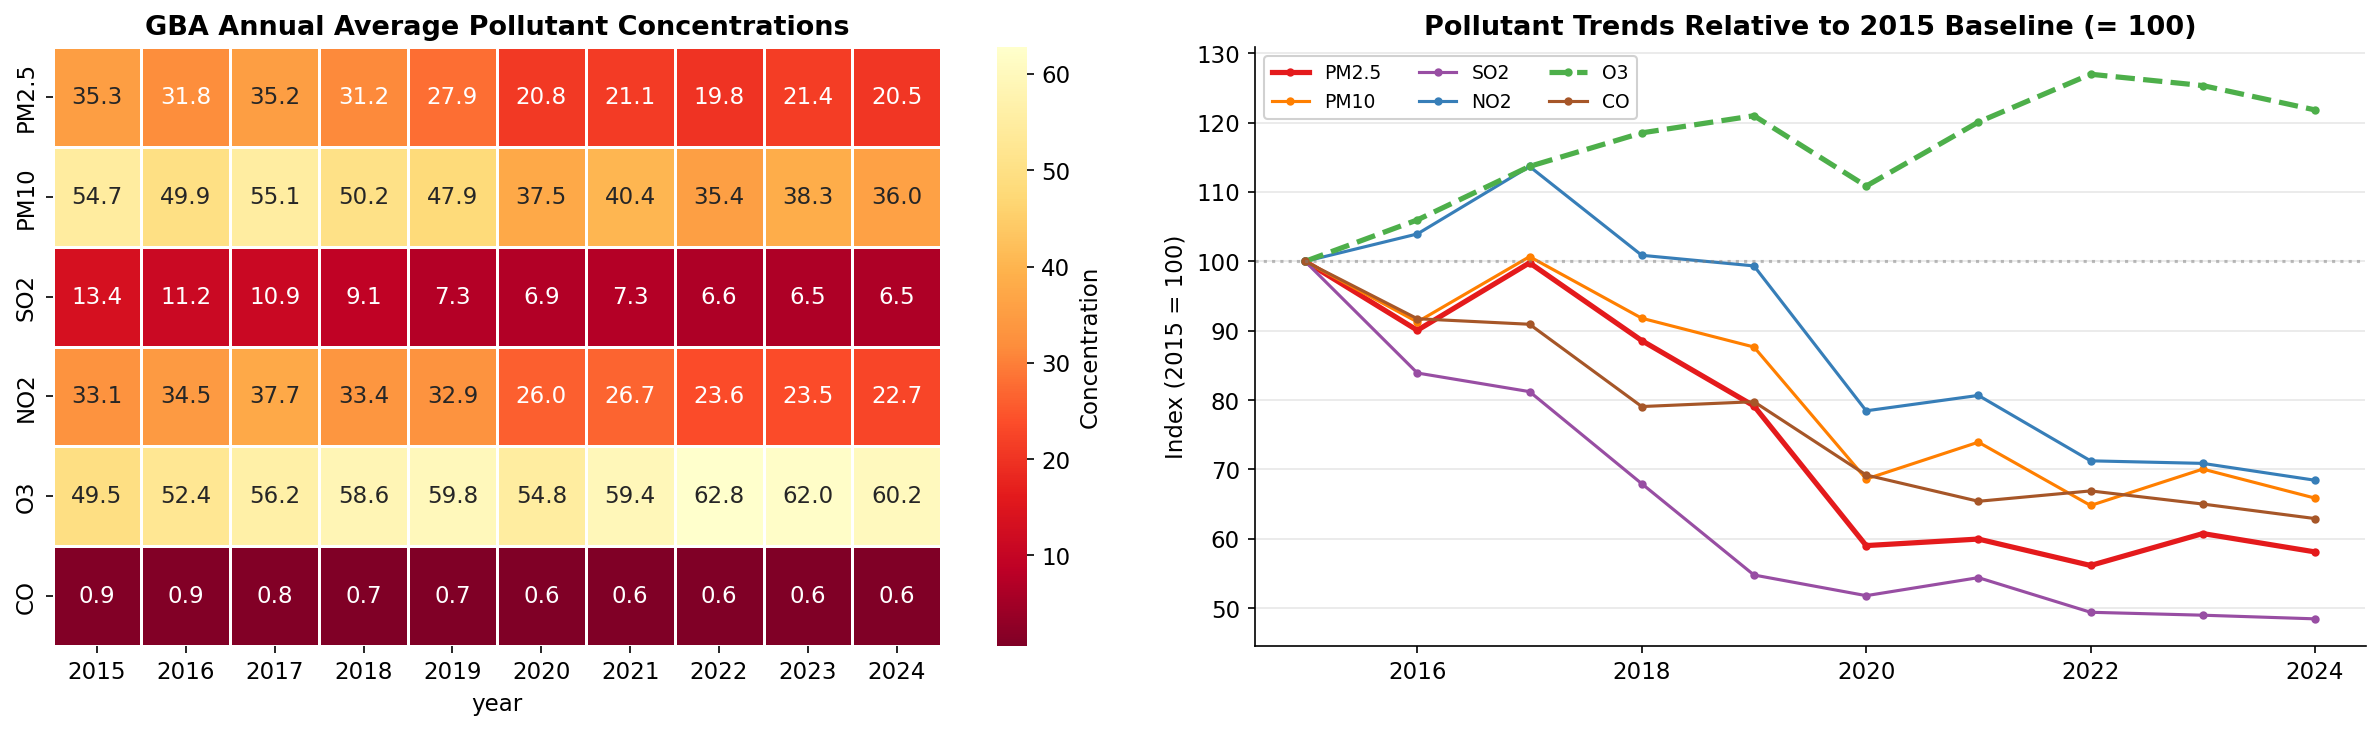


Key finding: PM2.5 declined ~40% while O3 rose ~30% over the decade.
This PM2.5-O3 divergence is a well-documented challenge in Chinese air quality management.


In [3]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3', 'CO']

# GBA-wide annual average (normalised to 2015 = 100)
annual_avg = df.groupby('year')[pollutants].mean()
normalised = annual_avg.div(annual_avg.iloc[0]) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: heatmap of absolute values
heatmap_data = annual_avg.T
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd_r', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Concentration'})
axes[0].set_title('GBA Annual Average Pollutant Concentrations', fontweight='bold')
axes[0].set_ylabel('')

# Right: normalised trend lines
colors = {'PM2.5': '#e41a1c', 'PM10': '#ff7f00', 'SO2': '#984ea3',
          'NO2': '#377eb8', 'O3': '#4daf4a', 'CO': '#a65628'}
for p in pollutants:
    style = '-' if p != 'O3' else '--'
    lw = 2.5 if p in ['PM2.5', 'O3'] else 1.5
    axes[1].plot(normalised.index, normalised[p], label=p, color=colors[p],
                linestyle=style, linewidth=lw, marker='o', markersize=3)

axes[1].axhline(y=100, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Pollutant Trends Relative to 2015 Baseline (= 100)', fontweight='bold')
axes[1].set_ylabel('Index (2015 = 100)')
axes[1].legend(ncol=3, framealpha=0.9)
axes[1].grid(axis='y', alpha=0.3)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('../outputs/pollutant_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nKey finding: PM2.5 declined ~40% while O3 rose ~30% over the decade.')
print('This PM2.5-O3 divergence is a well-documented challenge in Chinese air quality management.')

## 3. Seasonal Decomposition

Decomposing the PM2.5 signal into trend, seasonal, and residual components for Shenzhen and Foshan (cleanest vs most polluted GBA cities).

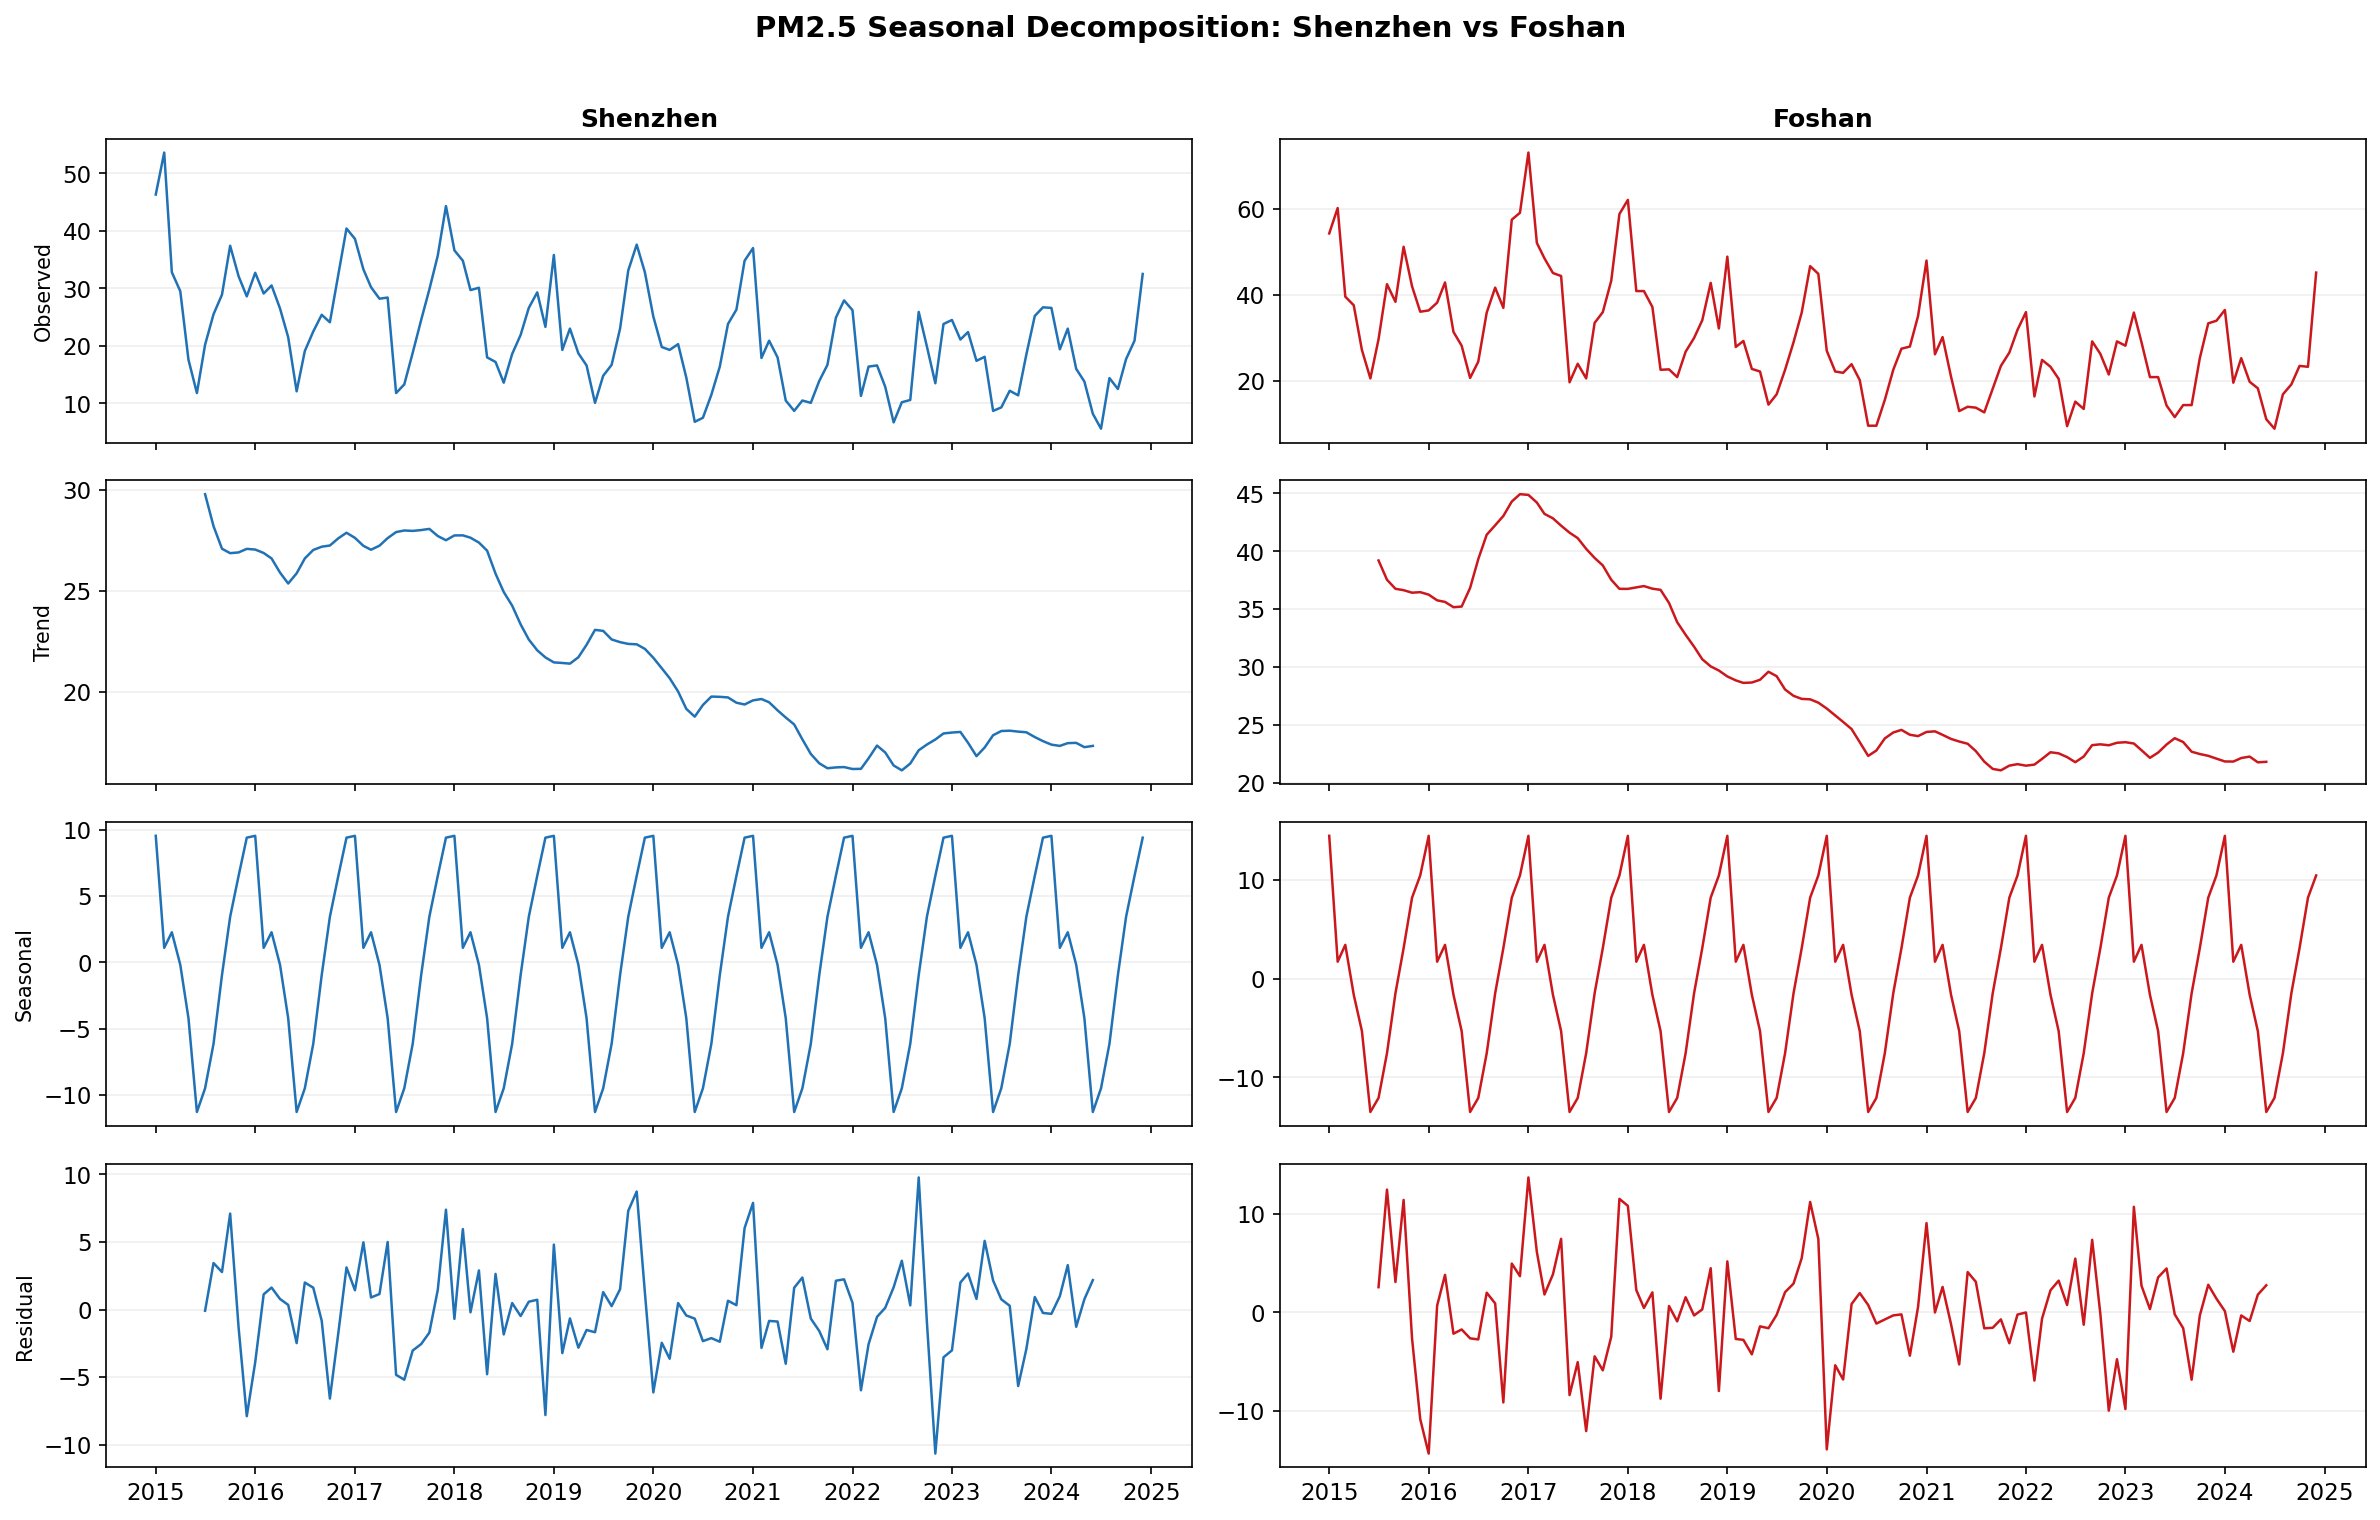

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)

for col, city in enumerate(['Shenzhen', 'Foshan']):
    ts = df[df['city'] == city].set_index('date')['PM2.5'].sort_index()
    decomp = seasonal_decompose(ts, model='additive', period=12)

    components = [('Observed', decomp.observed),
                  ('Trend', decomp.trend),
                  ('Seasonal', decomp.seasonal),
                  ('Residual', decomp.resid)]

    for row, (name, data) in enumerate(components):
        ax = axes[row, col]
        color = '#2171b5' if col == 0 else '#cb181d'
        ax.plot(data.index, data.values, color=color, linewidth=1.2)
        if col == 0:
            ax.set_ylabel(name, fontsize=10)
        if row == 0:
            ax.set_title(f'{city}', fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.2)

fig.suptitle('PM2.5 Seasonal Decomposition: Shenzhen vs Foshan', fontweight='bold',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/seasonal_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. COVID-19 Impact Analysis

Comparing Feb-Apr 2020 (lockdown period) against the same months in surrounding years to quantify the anomaly.

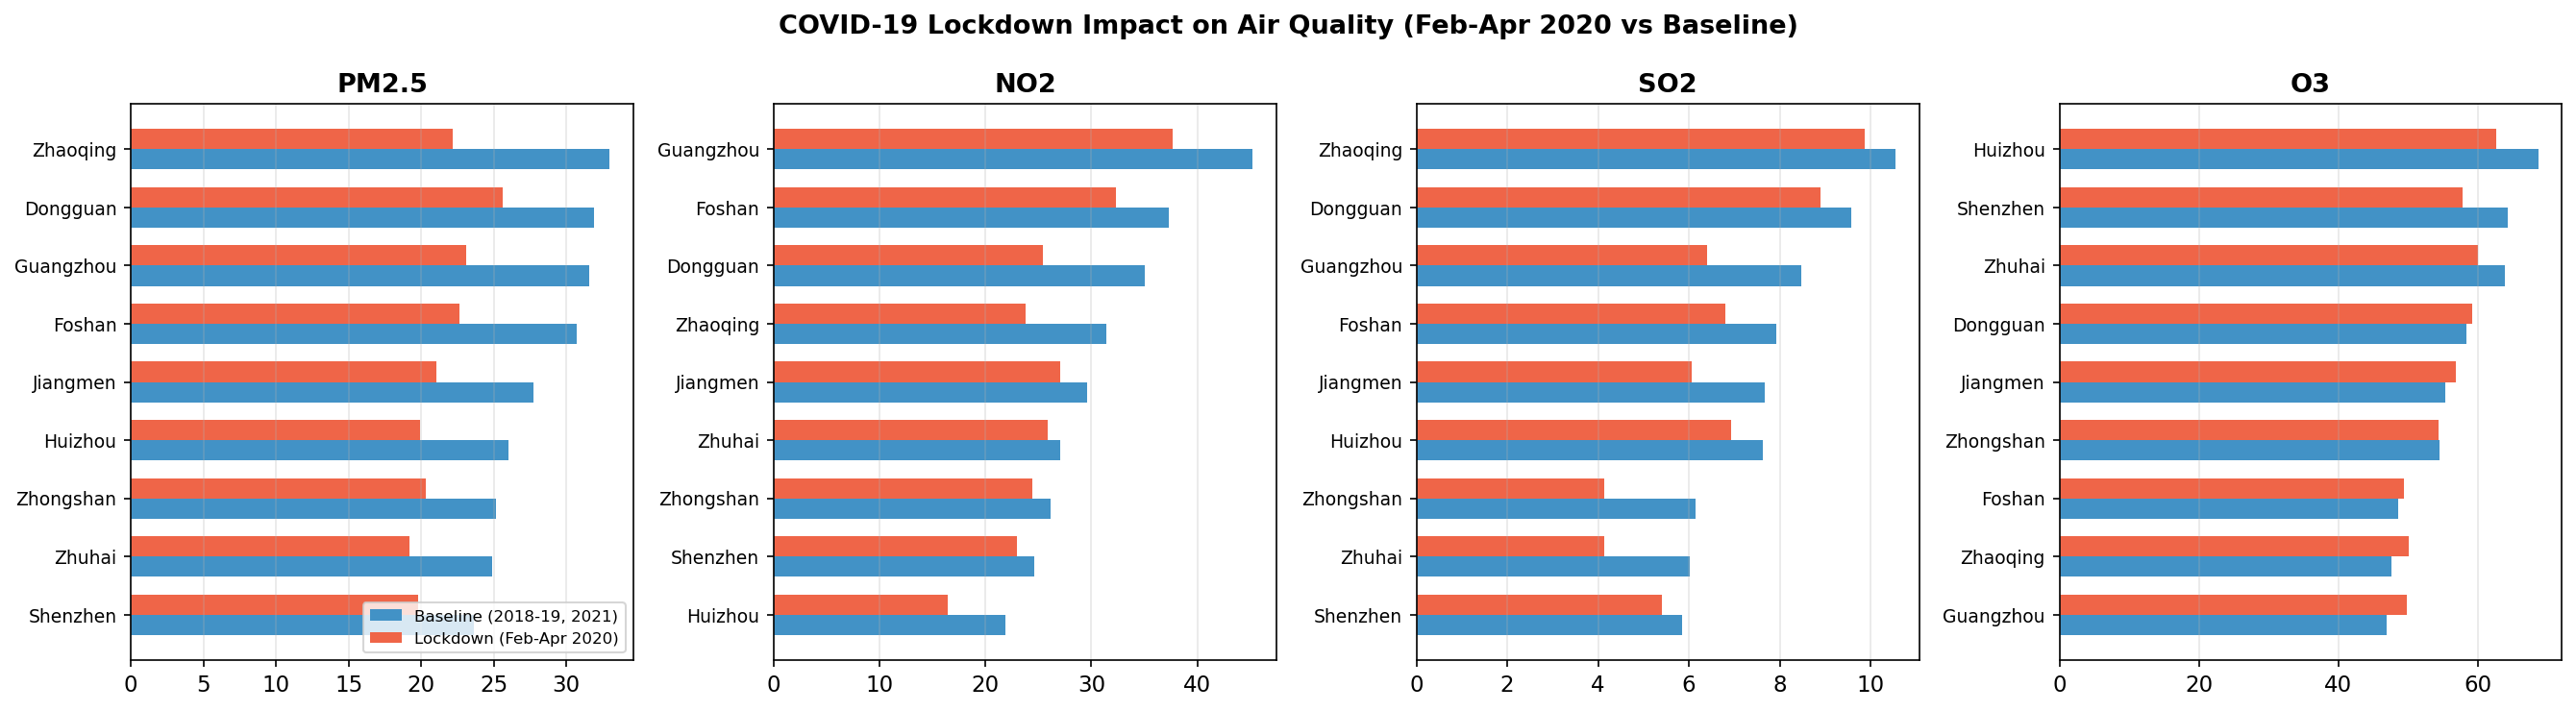


GBA-Wide Lockdown Impact (Feb-Apr 2020 vs baseline):
  PM2.5   : 28.3 → 21.5  (-23.9%)
  NO2     : 30.9 → 26.2  (-15.2%)
  SO2     : 7.8 → 6.5  (-16.0%)
  O3      : 56.5 → 55.6  (-1.6%)


In [5]:
target_months = [2, 3, 4]

# Baseline: average of 2018-2019 and 2021 for same months
baseline_years = [2018, 2019, 2021]
covid_year = 2020

pollutants_covid = ['PM2.5', 'NO2', 'SO2', 'O3']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, p in enumerate(pollutants_covid):
    ax = axes[idx]

    baseline = df[(df['year'].isin(baseline_years)) & (df['month'].isin(target_months))]
    lockdown = df[(df['year'] == covid_year) & (df['month'].isin(target_months))]

    baseline_city = baseline.groupby('city')[p].mean().sort_values()
    lockdown_city = lockdown.groupby('city')[p].mean().reindex(baseline_city.index)

    x = np.arange(len(baseline_city))
    w = 0.35
    ax.barh(x - w/2, baseline_city.values, w, label='Baseline (2018-19, 2021)', color='#4292c6')
    ax.barh(x + w/2, lockdown_city.values, w, label='Lockdown (Feb-Apr 2020)', color='#ef6548')

    ax.set_yticks(x)
    ax.set_yticklabels(baseline_city.index, fontsize=9)
    ax.set_title(p, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8, loc='lower right')

fig.suptitle('COVID-19 Lockdown Impact on Air Quality (Feb-Apr 2020 vs Baseline)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/covid_impact.png', dpi=200, bbox_inches='tight')
plt.show()

# Quantify
print('\nGBA-Wide Lockdown Impact (Feb-Apr 2020 vs baseline):')
print('=' * 50)
for p in pollutants_covid:
    bl = df[(df['year'].isin(baseline_years)) & (df['month'].isin(target_months))][p].mean()
    lk = df[(df['year'] == covid_year) & (df['month'].isin(target_months))][p].mean()
    pct = (lk - bl) / bl * 100
    print(f'  {p:8s}: {bl:.1f} → {lk:.1f}  ({pct:+.1f}%)')

## 5. City Comparison Radar Chart

Comparing the latest year (2024) pollution profiles across all 9 cities.

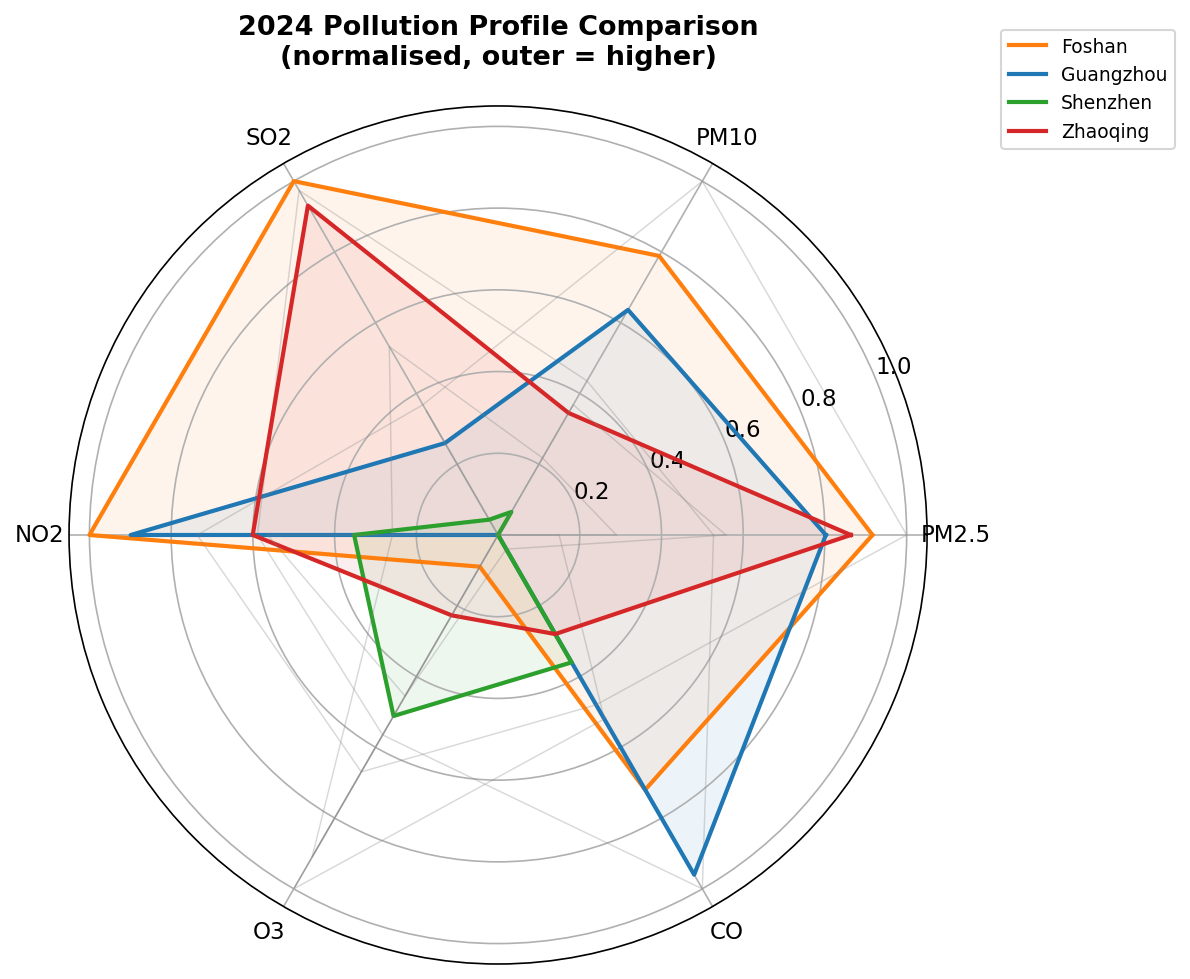

In [6]:
latest = df[df['year'] == 2024].groupby('city')[['PM2.5', 'PM10', 'SO2', 'NO2', 'O3', 'CO']].mean()

# Normalise each pollutant to 0-1 for radar
normalised_radar = (latest - latest.min()) / (latest.max() - latest.min())
categories = list(normalised_radar.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

highlight = ['Shenzhen', 'Guangzhou', 'Foshan', 'Zhaoqing']
highlight_colors = {'Shenzhen': '#2ca02c', 'Guangzhou': '#1f77b4',
                    'Foshan': '#ff7f0e', 'Zhaoqing': '#d62728'}

for city in normalised_radar.index:
    values = normalised_radar.loc[city].values.tolist()
    values += values[:1]
    if city in highlight:
        ax.plot(angles, values, linewidth=2, label=city, color=highlight_colors[city])
        ax.fill(angles, values, alpha=0.08, color=highlight_colors[city])
    else:
        ax.plot(angles, values, linewidth=0.7, alpha=0.3, color='gray')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('2024 Pollution Profile Comparison\n(normalised, outer = higher)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../outputs/city_comparison_radar.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Statistical Summary

Linear regression to quantify the annual rate of change for each pollutant across GBA.

In [7]:
print('Linear Trend Analysis: Annual Rate of Change (GBA-wide)')
print('=' * 65)
print(f'{"Pollutant":>10s}  {"Slope (per year)":>16s}  {"R²":>6s}  {"p-value":>10s}  Direction')
print('-' * 65)

gba_monthly = df.groupby('date')[pollutants].mean().sort_index()
gba_monthly['t'] = np.arange(len(gba_monthly)) / 12  # years

for p in pollutants:
    slope, intercept, r, pval, se = stats.linregress(gba_monthly['t'], gba_monthly[p])
    direction = '↓ Improving' if slope < 0 else '↑ Worsening'
    if p == 'O3' and slope > 0:
        direction = '↑ Worsening'
    elif p == 'O3' and slope < 0:
        direction = '↓ Improving'
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f'{p:>10s}  {slope:>+14.3f}/yr  {r**2:>6.3f}  {pval:>8.2e} {sig}  {direction}')

print('\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant')

Linear Trend Analysis: Annual Rate of Change (GBA-wide)
 Pollutant  Slope (per year)      R²     p-value  Direction
-----------------------------------------------------------------
     PM2.5          -1.936/yr   0.248  7.04e-09 ***  ↓ Improving
      PM10          -2.312/yr   0.182  1.14e-06 ***  ↓ Improving
       SO2          -0.722/yr   0.568  3.03e-23 ***  ↓ Improving
       NO2          -1.602/yr   0.208  1.67e-07 ***  ↓ Improving
        O3          +1.267/yr   0.072  3.15e-03 **  ↑ Worsening
        CO          -0.039/yr   0.523  1.13e-20 ***  ↓ Improving

Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


## Key Conclusions

1. **PM2.5 has declined significantly across all 9 GBA cities** (35-45% over the decade), driven by industrial restructuring, vehicle emission standards, and coal-to-gas transitions.

2. **O3 is the emerging challenge** — the only pollutant showing a statistically significant upward trend. This reflects the non-linear relationship between NOx, VOC, and O3 formation: as NOx falls, the photochemical regime can shift to produce more O3.

3. **COVID-19 lockdowns produced measurable but temporary improvements** in NO2 and PM2.5 (Feb-Apr 2020), with NO2 showing the largest response due to its close link to traffic emissions.

4. **Coastal cities (Shenzhen, Zhuhai) consistently outperform inland cities (Foshan, Zhaoqing)** in PM2.5, likely due to better ventilation, lower industrial density, and sea breeze effects.

5. **For policy**: the PM2.5-O3 co-control challenge requires coordinated reduction of both NOx and VOCs — a priority area for GBA environmental management going forward.

---
*Analysis by Haohang Zhao | April 2026*